In [16]:
### imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.rank_counts import create_filtered_rank_abundances_dict, create_qvalue_dict
from src.stats import empirical_sampling_comparison, transform_results_to_dataframe
import src.master_positions_handler as mph

In [ ]:
### loading combined data (all microbial domains) and placental data (as example domain-specific microbiome)
with open("data/ncbi_tax_dictionary11.json", 'r') as file:
    ncbi_taxonomy = json.load(file)

combined = pd.read_csv("data/counts/counts_combined.csv", header=None)
placental = pd.read_csv("data/counts/counts_placental.csv", header=None)

print(f"Combined: {len(combined[0])}, unique: {len(combined[0].unique())}")
print(f"Placental: {len(placental[0])}, unique: {len(placental[0].unique())}")

In [ ]:
### calculate q-values for placental vs combined
combined_rank_abundances_dict, _, _, _, _ = create_filtered_rank_abundances_dict(ncbi_taxonomy, combined[0])
placental_rank_abundances_dict, _, _, _, _ = create_filtered_rank_abundances_dict(ncbi_taxonomy, placental[0])
results_placental = empirical_sampling_comparison(combined_rank_abundances_dict, placental_rank_abundances_dict, n_samp=1000, fdr_method='storey')

df_placental = transform_results_to_dataframe(results_placental, ncbi_taxonomy)
df_placental = df_placental.sort_values(by='agg_count', ascending=False)

placental_rank_qvalues_dict = create_qvalue_dict(placental_rank_abundances_dict, results_placental)

df_placental

All ranks in ncbi_taxonomy: {'section', 'phylum', 'suborder', 'subclass', 'class', 'subfamily', 'genus', 'species', 'family', 'kingdom', 'clade', 'subphylum', 'order', 'superfamily', 'tribe', 'subkingdom', 'superkingdom', 'forma', 'subgenus'}
Number of IDs in df_ids: 182064
Total relevant taxa including parents: 7460
Added tax_id NCBI:txid1105181 as 'no rank'
Added tax_id NCBI:txid539003 as 'no rank'
Added tax_id NCBI:txid348841 as 'no rank'
Added tax_id NCBI:txid2626453 as 'no rank'
Added tax_id NCBI:txid41292 as 'no rank'
Added tax_id NCBI:txid469895 as 'no rank'
Added tax_id NCBI:txid59201 as 'no rank'
Added tax_id NCBI:txid1239388 as 'no rank'
Added tax_id NCBI:txid69409 as 'no rank'
Added tax_id NCBI:txid2720870 as 'no rank'
Added tax_id NCBI:txid2629415 as 'no rank'
Added tax_id NCBI:txid1539974 as 'no rank'
Added tax_id NCBI:txid67757 as 'no rank'
Added tax_id NCBI:txid1920255 as 'no rank'
Added tax_id NCBI:txid2720871 as 'no rank'
Added tax_id NCBI:txid260899 as 'no rank'
Added

,tax_id,rank,name1,name2,agg_count,q_value
24,NCBI:txid1578,genus,Lactobacillus,Lactobacillus,11.069364,0.276390
0,NCBI:txid2,superkingdom,Bacteria,Bacteria,9.140000,1.000000
13,NCBI:txid838,genus,Prevotella,Prevotella,7.005882,0.796079
204,NCBI:txid1239,phylum,Bacillaeota,Bacillaeota,7.000000,1.000000
33,NCBI:txid2701,genus,Gardnerella,Gardnerella,6.142857,0.014985
...,...,...,...,...,...,...
133,NCBI:txid1843489,order,Veillonellales,Veillonellales,0.000000,1.000000
134,NCBI:txid1853229,order,Chitinophagales,Chitinophagales,0.000000,1.000000
137,NCBI:txid2887326,order,Moraxellales,Moraxellales,0.000000,1.000000
205,NCBI:txid4890,phylum,Ascomycetes,ascomycetes,0.000000,1.000000


0.0 11.06936416184971
-0.0 1.8243428184236372


(array([103.,  19.,  17.,  25.,  30.,  19.,  19.,   7.,   9.,   5.]),
 array([0.        , 0.18243428, 0.36486856, 0.54730285, 0.72973713,
        0.91217141, 1.09460569, 1.27703997, 1.45947425, 1.64190854,
        1.82434282]),
 <BarContainer object of 10 artists>)

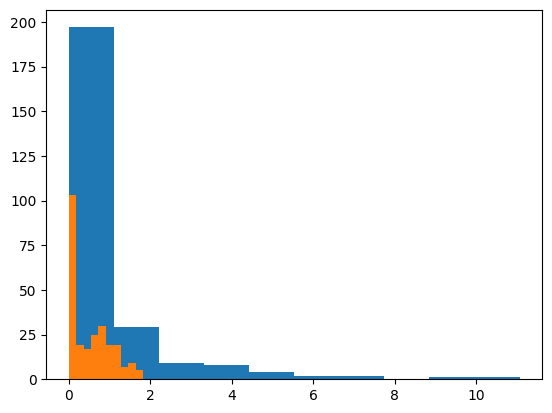

In [ ]:
### calculate min and max counts and plot histogram of counts and q-values
counts = [count for k, v in placental_rank_abundances_dict.items() for taxa, count in v.items()]
print(min(counts), max(counts))
plt.hist(counts)

counts_qvalue = [count for k, v in placental_rank_qvalues_dict.items() for taxa, count in v.items()]
print(min(counts_qvalue), max(counts_qvalue))
plt.hist(counts_qvalue)

In [ ]:
### master positions plotting

with open("data/ncbi_tax_dictionary11.json", 'r') as file:
    ncbi_taxonomy = json.load(file)

tax_id_2_name = {item['TaxID']: None for item in ncbi_taxonomy}
tax_id_2_name = {item['TaxID']: item['CleanName'] for item in ncbi_taxonomy if tax_id_2_name.get(item['TaxID']) is None}

# Generate master positions from combined microbiome data
combined = pd.read_csv("data/counts/counts_combined.csv", header=None)
combined_data = create_filtered_rank_abundances_dict(ncbi_taxonomy, combined[0])
master_positions = mph.generate_master_positions(combined_data, output_file="master_positions.pkl")

# load other microbiome data (placental here as example)
placental = pd.read_csv("data/counts/counts_placental.csv", header=None)

All ranks in ncbi_taxonomy: {'section', 'phylum', 'suborder', 'subclass', 'class', 'subfamily', 'genus', 'species', 'family', 'kingdom', 'clade', 'subphylum', 'order', 'superfamily', 'tribe', 'subkingdom', 'superkingdom', 'forma', 'subgenus'}
Number of IDs in df_ids: 182064
Total relevant taxa including parents: 7460
Added tax_id NCBI:txid1105181 as 'no rank'
Added tax_id NCBI:txid539003 as 'no rank'
Added tax_id NCBI:txid348841 as 'no rank'
Added tax_id NCBI:txid2626453 as 'no rank'
Added tax_id NCBI:txid41292 as 'no rank'
Added tax_id NCBI:txid469895 as 'no rank'
Added tax_id NCBI:txid59201 as 'no rank'
Added tax_id NCBI:txid1239388 as 'no rank'
Added tax_id NCBI:txid69409 as 'no rank'
Added tax_id NCBI:txid2720870 as 'no rank'
Added tax_id NCBI:txid2629415 as 'no rank'
Added tax_id NCBI:txid1539974 as 'no rank'
Added tax_id NCBI:txid67757 as 'no rank'
Added tax_id NCBI:txid1920255 as 'no rank'
Added tax_id NCBI:txid2720871 as 'no rank'
Added tax_id NCBI:txid260899 as 'no rank'
Added

All ranks in ncbi_taxonomy: {'section', 'phylum', 'suborder', 'subclass', 'class', 'subfamily', 'genus', 'species', 'family', 'kingdom', 'clade', 'subphylum', 'order', 'superfamily', 'tribe', 'subkingdom', 'superkingdom', 'forma', 'subgenus'}
Number of IDs in df_ids: 182064
Total relevant taxa including parents: 7460
Added tax_id NCBI:txid1105181 as 'no rank'
Added tax_id NCBI:txid539003 as 'no rank'
Added tax_id NCBI:txid348841 as 'no rank'
Added tax_id NCBI:txid2626453 as 'no rank'
Added tax_id NCBI:txid41292 as 'no rank'
Added tax_id NCBI:txid469895 as 'no rank'
Added tax_id NCBI:txid59201 as 'no rank'
Added tax_id NCBI:txid1239388 as 'no rank'
Added tax_id NCBI:txid69409 as 'no rank'
Added tax_id NCBI:txid2720870 as 'no rank'
Added tax_id NCBI:txid2629415 as 'no rank'
Added tax_id NCBI:txid1539974 as 'no rank'
Added tax_id NCBI:txid67757 as 'no rank'
Added tax_id NCBI:txid1920255 as 'no rank'
Added tax_id NCBI:txid2720871 as 'no rank'
Added tax_id NCBI:txid260899 as 'no rank'
Added

c:\Users\avish\Documents\PhD\Code\microbELP\tree-visualisation\src\master_positions_handler.py:695: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


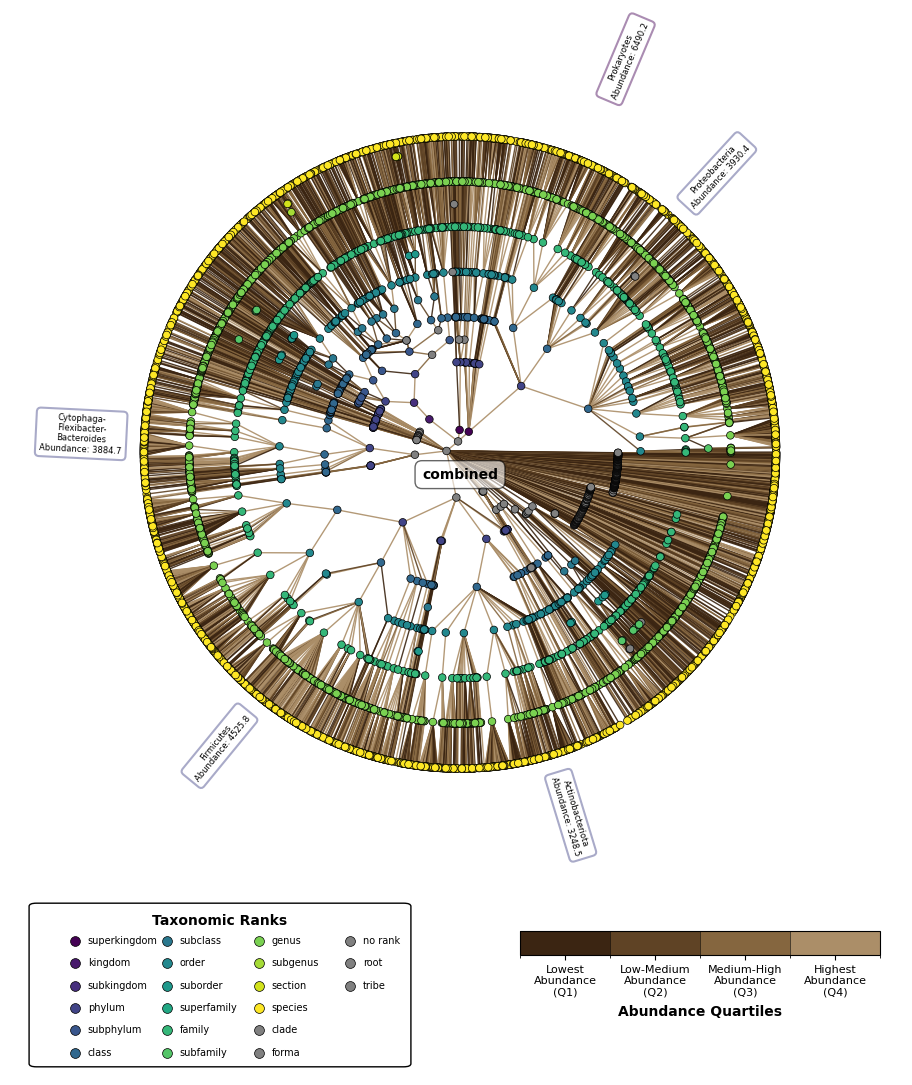

In [18]:
### plot combined microbiome data with master positions

surface = "combined"
dataset = combined

microbiome1_filtered_dict, microbiome1_parent_map, microbiome1_children_map, \
    microbiome1_rank_map, microbiome1_norm_value_map = \
    create_filtered_rank_abundances_dict(ncbi_taxonomy, dataset[0])

fig, ax = mph.plot_phylogenetic_tree_with_master_positions(
    microbiome1_filtered_dict, 
    microbiome1_parent_map, microbiome1_children_map,
    microbiome1_rank_map, microbiome1_norm_value_map, master_positions,
    tax_name_map=tax_id_2_name, figsize=(12, 12),
    surface_text=surface, output_file=f"saved-images/individual/{surface}_master.png",
    max_textbox_labels=5, edge_width=1
)

All ranks in ncbi_taxonomy: {'section', 'phylum', 'suborder', 'subclass', 'class', 'subfamily', 'genus', 'species', 'family', 'kingdom', 'clade', 'subphylum', 'order', 'superfamily', 'tribe', 'subkingdom', 'superkingdom', 'forma', 'subgenus'}
Number of IDs in df_ids: 248
Total relevant taxa including parents: 252
Added tax_id NCBI:txid68525 as 'no rank'
Added tax_id NCBI:txid2782232 as 'no rank'
Added tax_id NCBI:txid1783257 as 'no rank'
Added tax_id NCBI:txid1783234 as 'no rank'
Added tax_id NCBI:txid543314 as 'no rank'
Added tax_id NCBI:txid1798711 as 'no rank'
Added tax_id noParentIDinList as 'no rank'
Added tax_id NCBI:txid68336 as 'no rank'
Added tax_id NCBI:txid205932 as 'no rank'
Added tax_id NCBI:txid1783272 as 'no rank'
Could not find ranks for 10 taxa
Ranks before filtering: ['superkingdom', 'genus', 'species', 'order', 'family', 'subfamily', 'tribe', 'phylum', 'class', 'kingdom', 'subphylum', 'suborder', 'forma', 'clade', 'subclass', 'section', 'subkingdom', 'subgenus', 'sup

c:\Users\avish\Documents\PhD\Code\microbELP\tree-visualisation\src\master_positions_handler.py:695: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


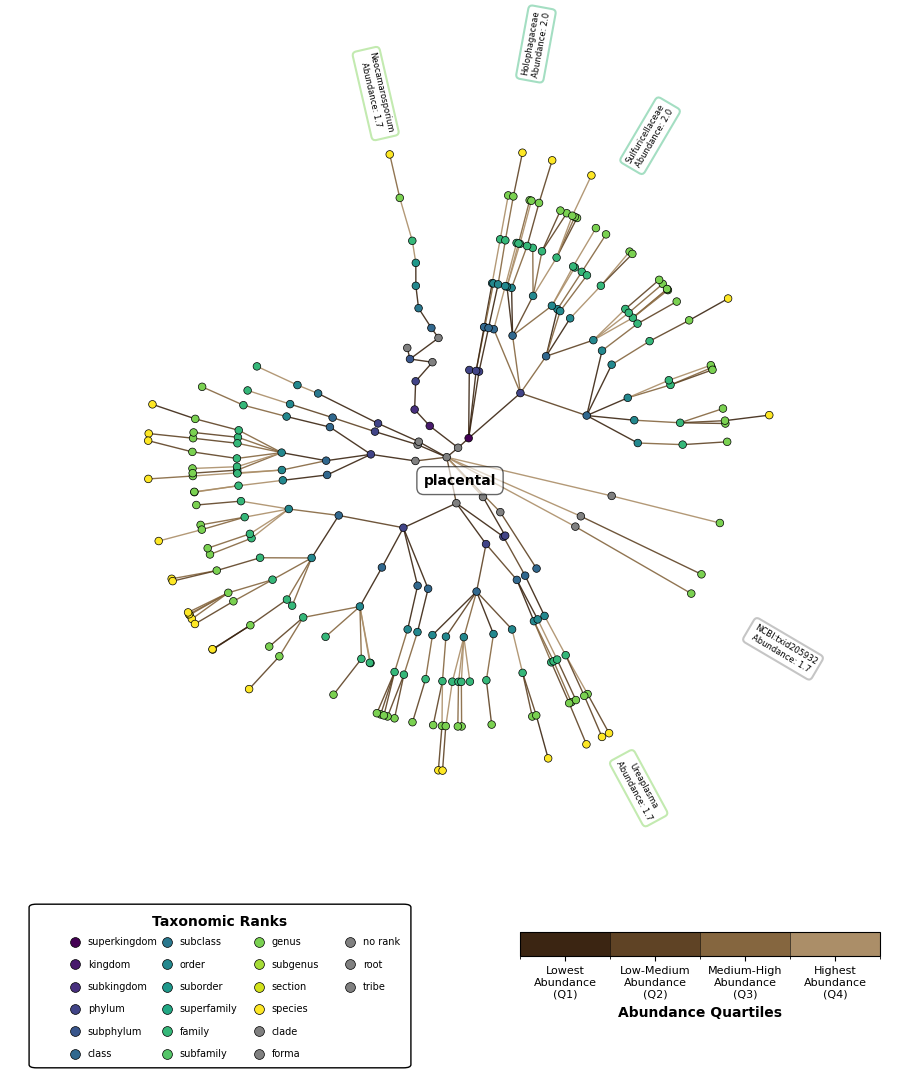

In [19]:
### plot placental microbiome data with master positions

# get placental and then plot my microbiome ids on top of it
placental_filtered_dict, placental_parent_map, placental_children_map, \
    placental_rank_map, placental_norm_value_map = \
    create_filtered_rank_abundances_dict(ncbi_taxonomy, placental[0])

results_placental = empirical_sampling_comparison(
    combined_data[0], placental_filtered_dict, n_samp=1000, fdr_method='storey')
placental_rank_qvalues_dict = create_qvalue_dict(placental_filtered_dict, results_placental)

fig, ax = mph.plot_phylogenetic_tree_with_master_positions(
    # placental_filtered_dict, 
    placental_rank_qvalues_dict,
    placental_parent_map, placental_children_map,
    placental_rank_map, placental_norm_value_map, master_positions,
    tax_name_map=tax_id_2_name, figsize=(12, 12),
    surface_text="placental", output_file=f"saved-images/individual/placental_master.png",
    max_textbox_labels=5, edge_width=1
)

All ranks in ncbi_taxonomy: {'section', 'phylum', 'suborder', 'subclass', 'class', 'subfamily', 'genus', 'species', 'family', 'kingdom', 'clade', 'subphylum', 'order', 'superfamily', 'tribe', 'subkingdom', 'superkingdom', 'forma', 'subgenus'}
Number of IDs in df_ids: 182064
Total relevant taxa including parents: 7460
Added tax_id NCBI:txid1105181 as 'no rank'
Added tax_id NCBI:txid539003 as 'no rank'
Added tax_id NCBI:txid348841 as 'no rank'
Added tax_id NCBI:txid2626453 as 'no rank'
Added tax_id NCBI:txid41292 as 'no rank'
Added tax_id NCBI:txid469895 as 'no rank'
Added tax_id NCBI:txid59201 as 'no rank'
Added tax_id NCBI:txid1239388 as 'no rank'
Added tax_id NCBI:txid69409 as 'no rank'
Added tax_id NCBI:txid2720870 as 'no rank'
Added tax_id NCBI:txid2629415 as 'no rank'
Added tax_id NCBI:txid1539974 as 'no rank'
Added tax_id NCBI:txid67757 as 'no rank'
Added tax_id NCBI:txid1920255 as 'no rank'
Added tax_id NCBI:txid2720871 as 'no rank'
Added tax_id NCBI:txid260899 as 'no rank'
Added

c:\Users\avish\Documents\PhD\Code\microbELP\tree-visualisation\src\overlay.py:461: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


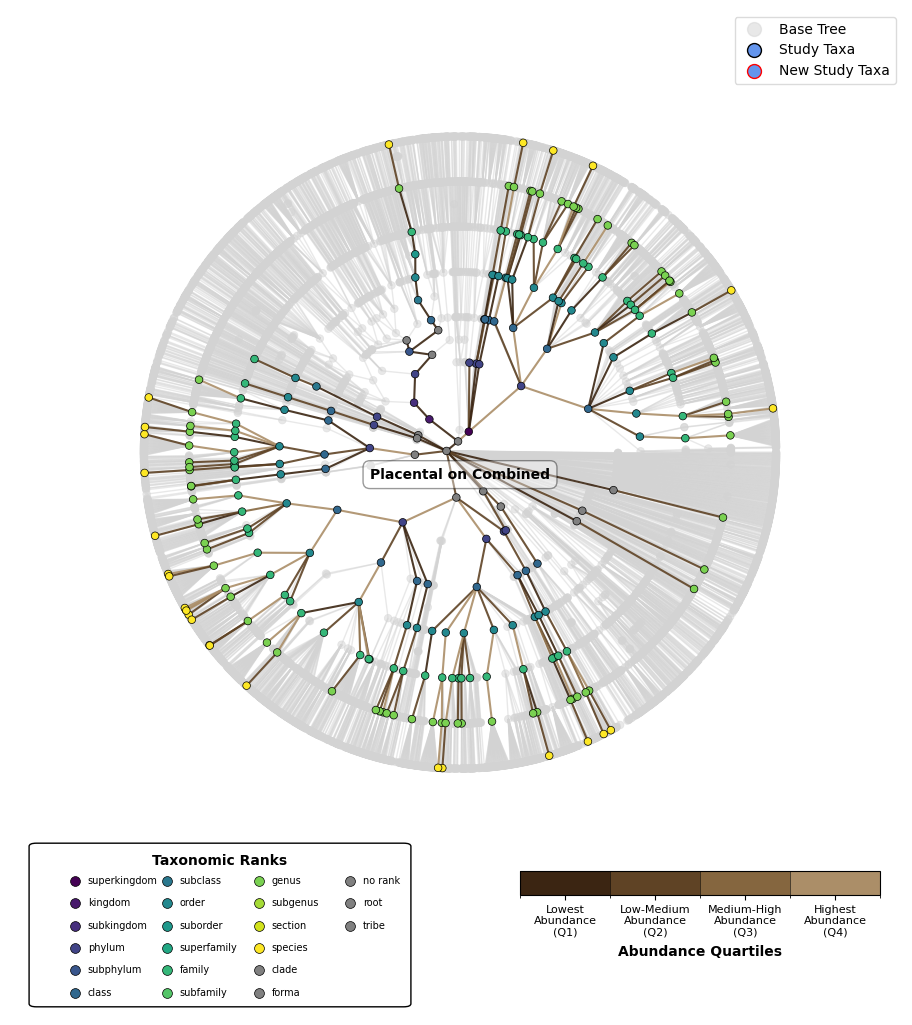

In [20]:
### plot placental microbiome data on top of combined microbiome data

from src.master_positions_handler import load_master_positions
from src.overlay import plot_study_dataset_on_tree
from src.rank_counts import create_filtered_rank_abundances_dict

# load ncbi taxonomy
with open("data/ncbi_tax_dictionary11.json", 'r') as file:
    ncbi_taxonomy = json.load(file)

# load base tree data (???)
combined = pd.read_csv("data/counts/counts_combined.csv", header=None)
base_tree_data = create_filtered_rank_abundances_dict(ncbi_taxonomy, combined[0])

# load master positions
master_positions_file = "master_positions.pkl"
master_positions = load_master_positions(master_positions_file)

# create tax_id_2_name mapping
tax_id_2_name = {item['TaxID']: None for item in ncbi_taxonomy}
tax_id_2_name = {item['TaxID']: item['CleanName'] for item in ncbi_taxonomy if tax_id_2_name.get(item['TaxID']) is None}

# load your study IDs (e.g., from a CSV file)
placental = pd.read_csv("data/counts/counts_placental.csv", header=None)
study_data = create_filtered_rank_abundances_dict(ncbi_taxonomy, placental[0])

# Plot study dataset on base tree
fig, ax = plot_study_dataset_on_tree(
    base_tree_data=base_tree_data,
    study_data=study_data,
    master_positions=master_positions,
    tax_name_map=tax_id_2_name,  # add your taxonomy name mapping if available
    figsize=(12, 12),
    output_file="saved-images/overlay/placental_on_combined.png",
    surface_text="Placental on Combined",
    edge_width=1
)

plt.show()